In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

In [2]:
# Generate sample data - 3 clusters in 2D
def generate_data():
    # Cluster 1: centered at (2, 2)
    cluster1 = torch.randn(40, 2) * 0.5 + torch.tensor([2.0, 2.0])
    
    # Cluster 2: centered at (7, 3)
    cluster2 = torch.randn(40, 2) * 0.5 + torch.tensor([7.0, 3.0])
    
    # Cluster 3: centered at (5, 8)
    cluster3 = torch.randn(40, 2) * 0.5 + torch.tensor([5.0, 8.0])
    
    # Combine all clusters
    data = torch.cat([cluster1, cluster2, cluster3], dim=0)
    
    # Shuffle data
    indices = torch.randperm(data.shape[0])
    data = data[indices]
    
    return data

# Generate data
X = generate_data()
print(f"Data shape: {X.shape}")
print(f"Data range: [{X.min():.2f}, {X.max():.2f}]")
print(f"First 5 data points:\n{X[:5]}")

Data shape: torch.Size([120, 2])
Data range: [0.90, 9.06]
First 5 data points:
tensor([[2.4504, 0.9472],
        [2.0390, 2.2629],
        [2.0283, 2.2131],
        [5.0966, 8.2048],
        [4.7137, 8.0418]])


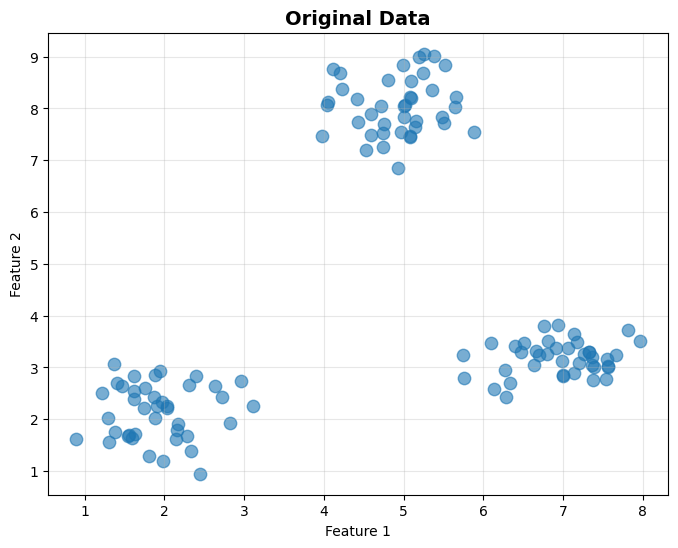

In [3]:
# Visualize the data
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], alpha=0.6, s=80)
plt.title('Original Data', fontsize=14, fontweight='bold')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True, alpha=0.3)
plt.show()

In [4]:
class SelfOrganizingMap:
    def __init__(self, map_size=(10, 10), input_dim=2, learning_rate=0.5, 
                 sigma=None, n_iterations=1000):
        """
        Self-Organizing Map (Kohonen Network) implementation from scratch
        
        Parameters:
        -----------
        map_size : tuple
            Size of the SOM grid (rows, cols)
        input_dim : int
            Dimensionality of input data
        learning_rate : float
            Initial learning rate
        sigma : float
            Initial neighborhood radius (default: max(map_size) / 2)
        n_iterations : int
            Number of training iterations
        """
        self.map_size = map_size
        self.input_dim = input_dim
        self.n_iterations = n_iterations
        self.initial_learning_rate = learning_rate
        
        # Set initial neighborhood radius
        if sigma is None:
            self.initial_sigma = max(map_size) / 2.0
        else:
            self.initial_sigma = sigma
        
        # Initialize weights randomly
        # Shape: (map_rows, map_cols, input_dim)
        self.weights = torch.randn(map_size[0], map_size[1], input_dim) * 0.1
        
        # Create coordinate grid for neurons
        self.neuron_positions = self._create_neuron_positions()
        
    def _create_neuron_positions(self):
        """
        Create a grid of neuron positions for distance calculations
        Returns tensor of shape (map_rows, map_cols, 2) with (row, col) coords
        """
        rows, cols = self.map_size
        positions = torch.zeros(rows, cols, 2)
        
        for i in range(rows):
            for j in range(cols):
                positions[i, j] = torch.tensor([i, j], dtype=torch.float32)
        
        return positions
    
    def find_bmu(self, input_vector):
        """
        Find Best Matching Unit (BMU) - neuron with weights closest to input
        
        Parameters:
        -----------
        input_vector : torch.Tensor
            Input sample of shape (input_dim,)
        
        Returns:
        --------
        bmu_position : tuple
            (row, col) position of BMU in the grid
        """
        # Compute Euclidean distance from input to all neurons
        # weights shape: (rows, cols, input_dim)
        # input_vector shape: (input_dim,)
        distances = torch.sum((self.weights - input_vector) ** 2, dim=2)
        distances = torch.sqrt(distances)
        
        # Find position of minimum distance
        flat_idx = torch.argmin(distances)
        bmu_row = flat_idx // self.map_size[1]
        bmu_col = flat_idx % self.map_size[1]
        
        return (bmu_row.item(), bmu_col.item())
    
    def compute_neighborhood(self, bmu_position, sigma):
        """
        Compute neighborhood function (Gaussian) for all neurons
        
        Parameters:
        -----------
        bmu_position : tuple
            (row, col) position of BMU
        sigma : float
            Current neighborhood radius
        
        Returns:
        --------
        neighborhood : torch.Tensor
            Shape (map_rows, map_cols) with neighborhood influence values
        """
        bmu_pos_tensor = torch.tensor([bmu_position[0], bmu_position[1]], dtype=torch.float32)
        
        # Compute distance from BMU to all neurons in grid
        distances = torch.sum((self.neuron_positions - bmu_pos_tensor) ** 2, dim=2)
        
        # Gaussian neighborhood function
        neighborhood = torch.exp(-distances / (2 * sigma ** 2))
        
        return neighborhood
    
    def update_weights(self, input_vector, bmu_position, learning_rate, sigma):
        """
        Update weights of BMU and its neighbors
        
        Weight update rule:
        w_new = w_old + learning_rate * neighborhood * (input - w_old)
        """
        # Compute neighborhood influence
        neighborhood = self.compute_neighborhood(bmu_position, sigma)
        
        # Expand dimensions for broadcasting
        # neighborhood: (rows, cols) -> (rows, cols, 1)
        neighborhood = neighborhood.unsqueeze(2)
        
        # Update weights
        # self.weights: (rows, cols, input_dim)
        # input_vector: (input_dim,)
        self.weights += learning_rate * neighborhood * (input_vector - self.weights)
    
    def decay_parameters(self, iteration):
        """
        Decay learning rate and neighborhood radius over time
        
        Uses exponential decay:
        - learning_rate = initial_rate * exp(-iteration / n_iterations)
        - sigma = initial_sigma * exp(-iteration / n_iterations)
        """
        time_constant = self.n_iterations / np.log(self.initial_sigma)
        
        learning_rate = self.initial_learning_rate * np.exp(-iteration / self.n_iterations)
        sigma = self.initial_sigma * np.exp(-iteration / time_constant)
        
        return learning_rate, sigma
    
    def fit(self, X, verbose=True):
        """
        Train the Self-Organizing Map
        
        Parameters:
        -----------
        X : torch.Tensor
            Training data of shape (n_samples, input_dim)
        verbose : bool
            Print training progress
        """
        n_samples = X.shape[0]
        
        if verbose:
            print(f"Training SOM with {self.map_size[0]}x{self.map_size[1]} grid")
            print(f"Input dimension: {self.input_dim}")
            print(f"Initial learning rate: {self.initial_learning_rate}")
            print(f"Initial sigma: {self.initial_sigma}")
            print(f"Iterations: {self.n_iterations}\n")
        
        for iteration in range(self.n_iterations):
            # Randomly select a training sample
            idx = torch.randint(0, n_samples, (1,)).item()
            input_vector = X[idx]
            
            # Find Best Matching Unit
            bmu_position = self.find_bmu(input_vector)
            
            # Decay learning rate and sigma
            learning_rate, sigma = self.decay_parameters(iteration)
            
            # Update weights
            self.update_weights(input_vector, bmu_position, learning_rate, sigma)
            
            # Print progress
            if verbose and (iteration % (self.n_iterations // 10) == 0 or iteration == self.n_iterations - 1):
                print(f"Iteration {iteration:4d}/{self.n_iterations}: "
                      f"LR = {learning_rate:.4f}, Sigma = {sigma:.4f}")
        
        if verbose:
            print("\nTraining completed!")
        
        return self
    
    def predict(self, X):
        """
        Map input samples to their BMU positions
        
        Parameters:
        -----------
        X : torch.Tensor
            Data of shape (n_samples, input_dim)
        
        Returns:
        --------
        bmu_positions : list of tuples
            BMU (row, col) positions for each input sample
        """
        bmu_positions = []
        for i in range(X.shape[0]):
            bmu_pos = self.find_bmu(X[i])
            bmu_positions.append(bmu_pos)
        return bmu_positions
    
    def get_u_matrix(self):
        """
        Compute U-Matrix (Unified Distance Matrix)
        Shows average distance between each neuron and its neighbors
        
        Returns:
        --------
        u_matrix : torch.Tensor
            Shape (map_rows, map_cols) with average distances
        """
        rows, cols = self.map_size
        u_matrix = torch.zeros(rows, cols)
        
        for i in range(rows):
            for j in range(cols):
                neighbors = []
                
                # Get all valid neighbors (up, down, left, right)
                if i > 0:  # up
                    neighbors.append(self.weights[i-1, j])
                if i < rows - 1:  # down
                    neighbors.append(self.weights[i+1, j])
                if j > 0:  # left
                    neighbors.append(self.weights[i, j-1])
                if j < cols - 1:  # right
                    neighbors.append(self.weights[i, j+1])
                
                # Compute average distance to neighbors
                if len(neighbors) > 0:
                    distances = [torch.norm(self.weights[i, j] - n) for n in neighbors]
                    u_matrix[i, j] = sum(distances) / len(distances)
        
        return u_matrix

In [5]:
# Create and train SOM
som = SelfOrganizingMap(
    map_size=(10, 10),
    input_dim=2,
    learning_rate=0.5,
    sigma=None,  # Will use max(map_size)/2 = 5.0
    n_iterations=1000
)

som.fit(X)

Training SOM with 10x10 grid
Input dimension: 2
Initial learning rate: 0.5
Initial sigma: 5.0
Iterations: 1000

Iteration    0/1000: LR = 0.5000, Sigma = 5.0000
Iteration  100/1000: LR = 0.4524, Sigma = 4.2567
Iteration  200/1000: LR = 0.4094, Sigma = 3.6239
Iteration  300/1000: LR = 0.3704, Sigma = 3.0852
Iteration  400/1000: LR = 0.3352, Sigma = 2.6265
Iteration  500/1000: LR = 0.3033, Sigma = 2.2361
Iteration  600/1000: LR = 0.2744, Sigma = 1.9037
Iteration  700/1000: LR = 0.2483, Sigma = 1.6207
Iteration  800/1000: LR = 0.2247, Sigma = 1.3797
Iteration  900/1000: LR = 0.2033, Sigma = 1.1746
Iteration  999/1000: LR = 0.1841, Sigma = 1.0016

Training completed!


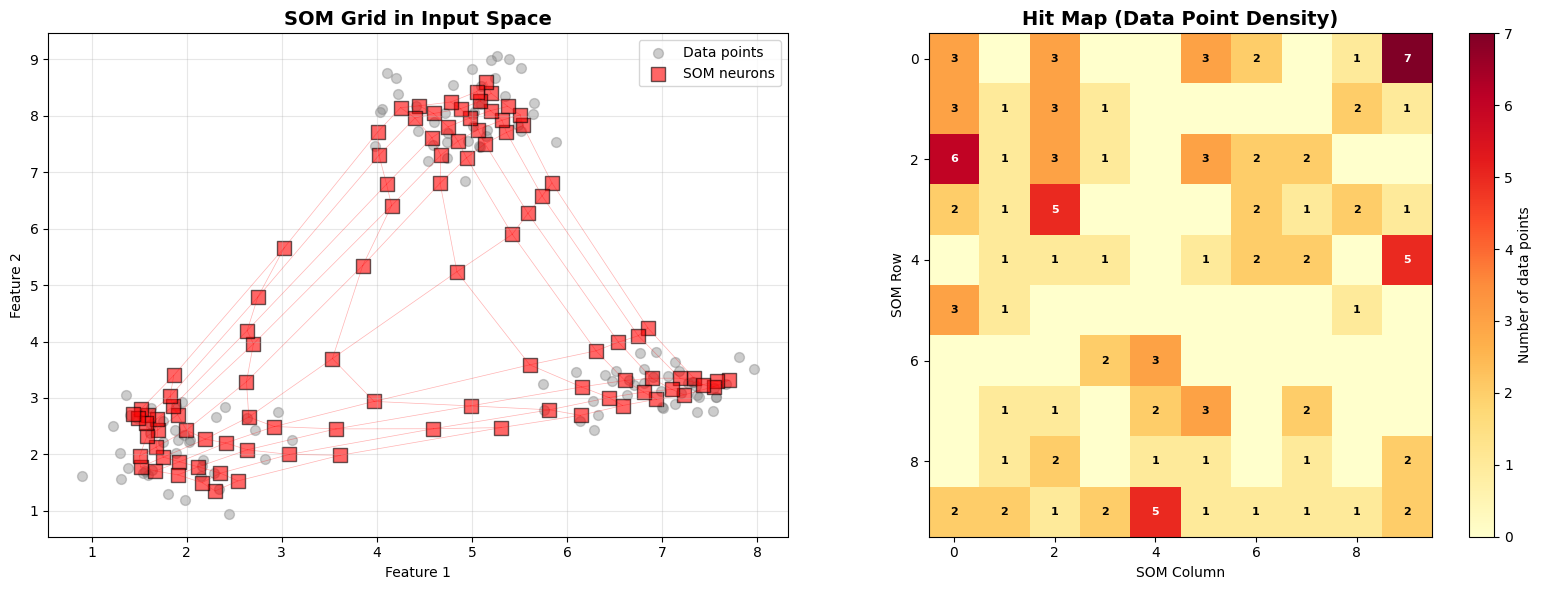

In [6]:
# Get BMU positions for all data points
bmu_positions = som.predict(X)

# Visualize the SOM grid and data mappings
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Original data space with SOM neuron weights
ax1 = axes[0]
ax1.scatter(X[:, 0], X[:, 1], alpha=0.4, s=50, c='gray', label='Data points')

# Plot SOM neuron weights as a grid
weights_reshaped = som.weights.view(-1, 2)  # Flatten to (rows*cols, 2)
ax1.scatter(weights_reshaped[:, 0], weights_reshaped[:, 1], 
           c='red', s=100, marker='s', alpha=0.6, edgecolors='black', 
           linewidths=1, label='SOM neurons')

# Draw grid connections
for i in range(som.map_size[0]):
    for j in range(som.map_size[1]):
        # Horizontal connections
        if j < som.map_size[1] - 1:
            w1 = som.weights[i, j]
            w2 = som.weights[i, j+1]
            ax1.plot([w1[0], w2[0]], [w1[1], w2[1]], 'r-', alpha=0.3, linewidth=0.5)
        # Vertical connections
        if i < som.map_size[0] - 1:
            w1 = som.weights[i, j]
            w2 = som.weights[i+1, j]
            ax1.plot([w1[0], w2[0]], [w1[1], w2[1]], 'r-', alpha=0.3, linewidth=0.5)

ax1.set_title('SOM Grid in Input Space', fontsize=14, fontweight='bold')
ax1.set_xlabel('Feature 1')
ax1.set_ylabel('Feature 2')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Hit map - shows which neurons were activated by data points
ax2 = axes[1]
hit_map = torch.zeros(som.map_size)
for pos in bmu_positions:
    hit_map[pos[0], pos[1]] += 1

im = ax2.imshow(hit_map, cmap='YlOrRd', interpolation='nearest')
ax2.set_title('Hit Map (Data Point Density)', fontsize=14, fontweight='bold')
ax2.set_xlabel('SOM Column')
ax2.set_ylabel('SOM Row')
plt.colorbar(im, ax=ax2, label='Number of data points')

# Add text annotations for counts
for i in range(som.map_size[0]):
    for j in range(som.map_size[1]):
        count = int(hit_map[i, j].item())
        if count > 0:
            ax2.text(j, i, str(count), ha='center', va='center', 
                    color='white' if count > hit_map.max()/2 else 'black',
                    fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

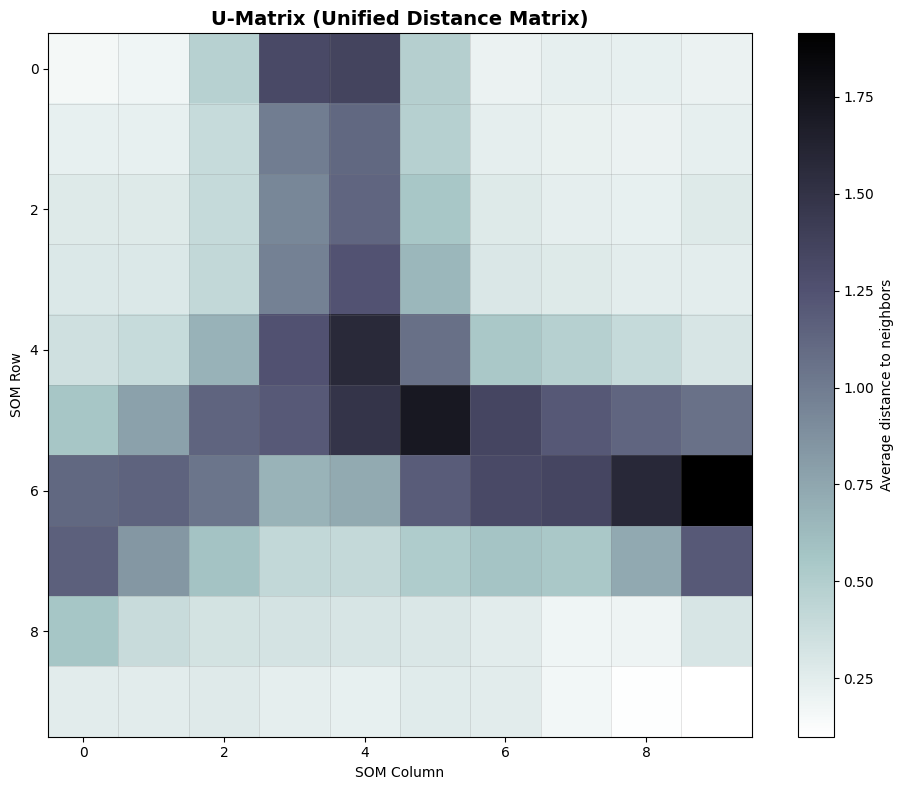


U-Matrix Interpretation:
- Light regions: Neurons are similar (within clusters)
- Dark regions: Large distances between neurons (cluster boundaries)


In [7]:
# Compute and visualize U-Matrix
u_matrix = som.get_u_matrix()

plt.figure(figsize=(10, 8))
im = plt.imshow(u_matrix, cmap='bone_r', interpolation='nearest')
plt.title('U-Matrix (Unified Distance Matrix)', fontsize=14, fontweight='bold')
plt.xlabel('SOM Column')
plt.ylabel('SOM Row')
plt.colorbar(im, label='Average distance to neighbors')

# Add grid
for i in range(som.map_size[0] + 1):
    plt.axhline(i - 0.5, color='gray', linewidth=0.5, alpha=0.3)
for j in range(som.map_size[1] + 1):
    plt.axvline(j - 0.5, color='gray', linewidth=0.5, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nU-Matrix Interpretation:")
print("- Light regions: Neurons are similar (within clusters)")
print("- Dark regions: Large distances between neurons (cluster boundaries)")

In [8]:
print("=" * 60)
print("SIMPLE EXAMPLE: 4 Points with Small SOM")
print("=" * 60)

# Create 4 simple data points
simple_data = torch.tensor([
    [1.0, 1.0],
    [1.5, 2.0],
    [5.0, 8.0],
    [8.0, 8.0]
])

print(f"\nData points:")
for i, point in enumerate(simple_data):
    print(f"  P{i+1}: {point.tolist()}")

# Create small SOM (3x3 grid)
print("\nTraining 3x3 SOM...\n")
som_simple = SelfOrganizingMap(
    map_size=(3, 3),
    input_dim=2,
    learning_rate=0.5,
    sigma=1.5,
    n_iterations=500
)

# Initialize weights in data range
som_simple.weights = torch.rand(3, 3, 2) * 8.0 + 1.0

som_simple.fit(simple_data, verbose=False)

# Get BMU for each point
simple_bmus = som_simple.predict(simple_data)
print("\nBest Matching Units:")
for i, (point, bmu) in enumerate(zip(simple_data, simple_bmus)):
    print(f"  P{i+1} {point.tolist()} -> Neuron at position {bmu}")

SIMPLE EXAMPLE: 4 Points with Small SOM

Data points:
  P1: [1.0, 1.0]
  P2: [1.5, 2.0]
  P3: [5.0, 8.0]
  P4: [8.0, 8.0]

Training 3x3 SOM...


Best Matching Units:
  P1 [1.0, 1.0] -> Neuron at position (0, 2)
  P2 [1.5, 2.0] -> Neuron at position (0, 1)
  P3 [5.0, 8.0] -> Neuron at position (2, 1)
  P4 [8.0, 8.0] -> Neuron at position (2, 0)


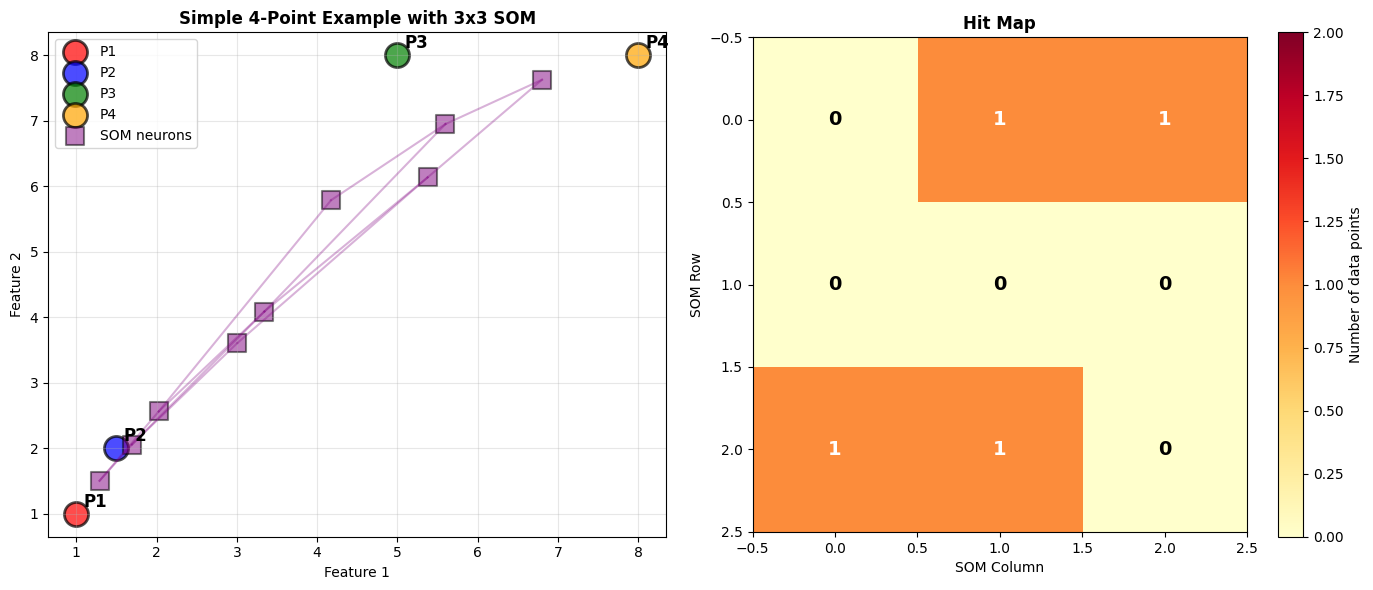

In [9]:
# Visualize simple example
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Data points with SOM neurons
ax1 = axes[0]
colors_simple = ['red', 'blue', 'green', 'orange']
for i, point in enumerate(simple_data):
    ax1.scatter(point[0], point[1], c=colors_simple[i], s=300, 
               label=f'P{i+1}', alpha=0.7, edgecolors='black', linewidths=2)
    ax1.annotate(f'P{i+1}', xy=point, xytext=(5, 5), 
                textcoords='offset points', fontsize=12, fontweight='bold')

# Plot SOM neurons
weights_simple = som_simple.weights.view(-1, 2)
ax1.scatter(weights_simple[:, 0], weights_simple[:, 1], 
           c='purple', s=150, marker='s', alpha=0.5, 
           edgecolors='black', linewidths=1.5, label='SOM neurons')

# Draw grid connections
for i in range(3):
    for j in range(3):
        if j < 2:
            w1 = som_simple.weights[i, j]
            w2 = som_simple.weights[i, j+1]
            ax1.plot([w1[0], w2[0]], [w1[1], w2[1]], 'purple', alpha=0.3, linewidth=1.5)
        if i < 2:
            w1 = som_simple.weights[i, j]
            w2 = som_simple.weights[i+1, j]
            ax1.plot([w1[0], w2[0]], [w1[1], w2[1]], 'purple', alpha=0.3, linewidth=1.5)

ax1.set_title('Simple 4-Point Example with 3x3 SOM', fontsize=12, fontweight='bold')
ax1.set_xlabel('Feature 1')
ax1.set_ylabel('Feature 2')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Hit map
ax2 = axes[1]
hit_map_simple = torch.zeros((3, 3))
for pos in simple_bmus:
    hit_map_simple[pos[0], pos[1]] += 1

im = ax2.imshow(hit_map_simple, cmap='YlOrRd', interpolation='nearest', vmin=0, vmax=2)
ax2.set_title('Hit Map', fontsize=12, fontweight='bold')
ax2.set_xlabel('SOM Column')
ax2.set_ylabel('SOM Row')
plt.colorbar(im, ax=ax2, label='Number of data points')

# Add annotations
for i in range(3):
    for j in range(3):
        count = int(hit_map_simple[i, j].item())
        ax2.text(j, i, str(count), ha='center', va='center',
                color='white' if count > 0 else 'black',
                fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [10]:
# Train a new SOM and capture snapshots
print("Training SOM and capturing snapshots...\n")

som_progress = SelfOrganizingMap(
    map_size=(8, 8),
    input_dim=2,
    learning_rate=0.5,
    n_iterations=600
)

# Store weight snapshots at different iterations
snapshots = []
snapshot_iterations = [0, 100, 300, 600]

for iteration in range(601):
    if iteration in snapshot_iterations:
        snapshots.append(som_progress.weights.clone())
    
    if iteration < 600:
        idx = torch.randint(0, X.shape[0], (1,)).item()
        input_vector = X[idx]
        bmu_position = som_progress.find_bmu(input_vector)
        learning_rate, sigma = som_progress.decay_parameters(iteration)
        som_progress.update_weights(input_vector, bmu_position, learning_rate, sigma)

print("Done! Visualizing progress...")

Training SOM and capturing snapshots...

Done! Visualizing progress...


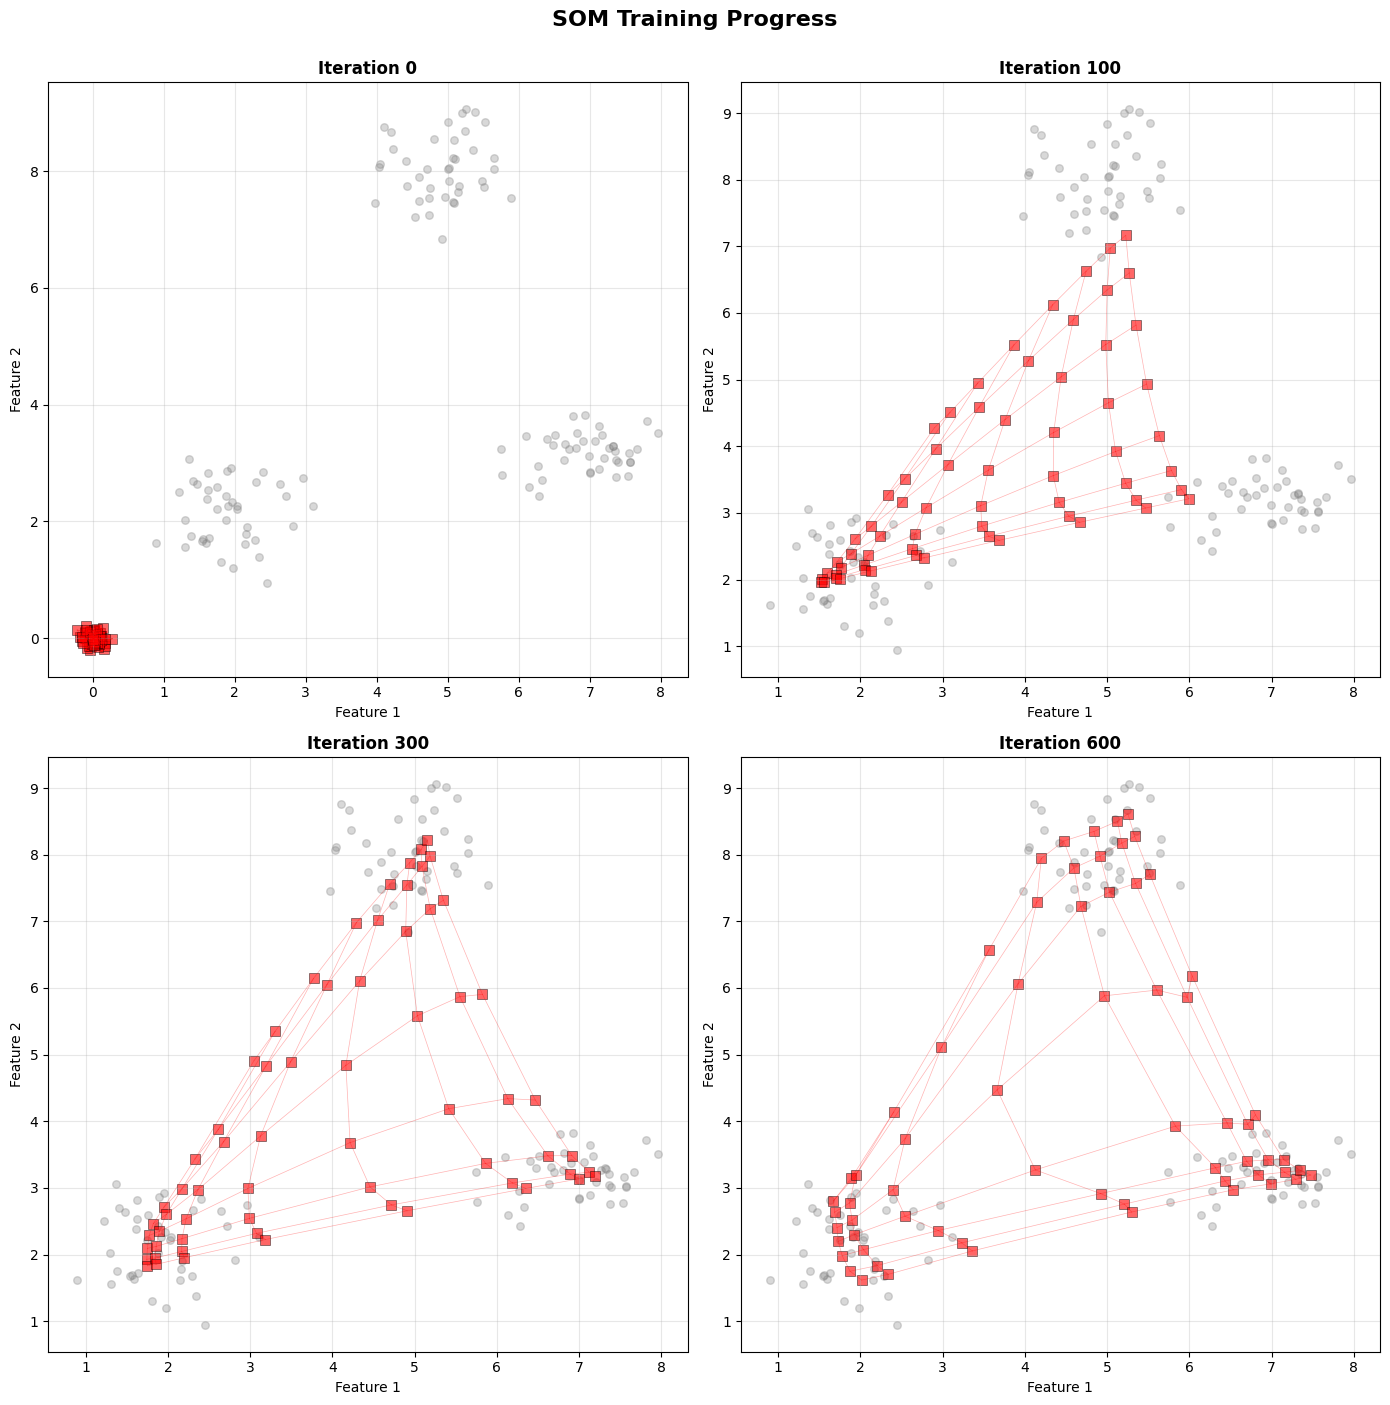

In [11]:
# Visualize training progress
fig, axes = plt.subplots(2, 2, figsize=(14, 14))
axes = axes.flatten()

for idx, (snapshot, iteration) in enumerate(zip(snapshots, snapshot_iterations)):
    ax = axes[idx]
    
    # Plot data points
    ax.scatter(X[:, 0], X[:, 1], alpha=0.3, s=30, c='gray')
    
    # Plot SOM neurons from snapshot
    weights = snapshot.view(-1, 2)
    ax.scatter(weights[:, 0], weights[:, 1], c='red', s=60, 
              marker='s', alpha=0.6, edgecolors='black', linewidths=0.5)
    
    # Draw grid
    for i in range(8):
        for j in range(8):
            if j < 7:
                w1 = snapshot[i, j]
                w2 = snapshot[i, j+1]
                ax.plot([w1[0], w2[0]], [w1[1], w2[1]], 'r-', alpha=0.3, linewidth=0.5)
            if i < 7:
                w1 = snapshot[i, j]
                w2 = snapshot[i+1, j]
                ax.plot([w1[0], w2[0]], [w1[1], w2[1]], 'r-', alpha=0.3, linewidth=0.5)
    
    ax.set_title(f'Iteration {iteration}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.grid(True, alpha=0.3)

plt.suptitle('SOM Training Progress', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()